# Pandas Query

## Required Imports

In [16]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

## Data Sources

### Utility functions

In [17]:
def get_df(file_name: str):
  filepath = Path("..")/"data"/file_name
  return pd.read_csv(filepath, index_col=0)

### Sources

In [18]:
australia_sweden_gdp = get_df('australia_sweden_gdp.csv')
australia_sweden_population = get_df('australia_sweden_population.csv')

## `pandas.DataFrame.query()`

## Syntax
```python
pandas.DataFrame.query(expr, inplace=False, **kwargs)
```
Filters rows using a string expression — a cleaner alternative to boolean indexing.
### Example
```python
import pandas as pd
df = pd.DataFrame({
    "name": ["Alice", "Bob", "Carol", "Dave"],
    "age":  [25, 30, 22, 35],
    "score": [88, 72, 95, 60]
})
# Boolean indexing (verbose)
df[df["age"] > 25]
# query() equivalent (clean)
df.query("age > 25")
```
## Expressions - `expr`
### Comparison operators
```python
df.query("age == 30")
df.query("age != 30")
df.query("score >= 80")
df.query("20 < age < 32")   # chained comparison supported
```
### Logical operators
```python
df.query("age > 25 and score >= 80")
df.query("age < 25 or score > 90")
df.query("not (age > 30)")
```
### `in` / `not in`
```python
df.query("name in ['Alice', 'Carol']")
df.query("name not in ['Bob']")
```
### Referencing Python Variables with `@`
Use `@` to inject local variables into the expression.
```python
min_age = 25
df.query("age > @min_age")

names = ["Alice", "Dave"]
df.query("name in @names")
```
### Column Names with Spaces
Use backticks for column names that contain spaces or special characters.
```python
df2 = pd.DataFrame({"`first name`": ["Alice"], "test score": [88]})
df2.query("`test score` > 80")
```
## `inplace` Parameter
```python
df.query("age > 25", inplace=True)   # modifies df directly
```
## Real-Life Example: Sales Data Filtering
```python
import pandas as pd
sales = pd.DataFrame({
    "region":   ["North", "South", "East", "West", "North"],
    "product":  ["A", "B", "A", "C", "C"],
    "revenue":  [12000, 8500, 15000, 4200, 9800],
    "units":    [120, 85, 200, 42, 95],
    "year":     [2023, 2023, 2024, 2024, 2024]
})
# Filter: North region, 2024, revenue above 5000
target_regions = ["North", "East"]
min_revenue = 5000
result = sales.query(
    "region in @target_regions and year == 2024 and revenue > @min_revenue"
)
print(result)
#   region product  revenue  units  year
# 2   East       A    15000    200  2024
# 4  North       C     9800     95  2024
```
## Key Differences vs Boolean Indexing
| Feature                | `query()`                   | Boolean Indexing         |
| ---------------------- | --------------------------- | ------------------------ |
| Readability            | High (string expression)    | Lower (verbose)          |


### Variable aliases

In [19]:
gdp = australia_sweden_gdp
pop = australia_sweden_population

### Real Life Example: Australia & Sweden GDP Per Capita

In [20]:
print(gdp.columns)

Index(['date', 'country', 'gdp', 'series_code'], dtype='str')


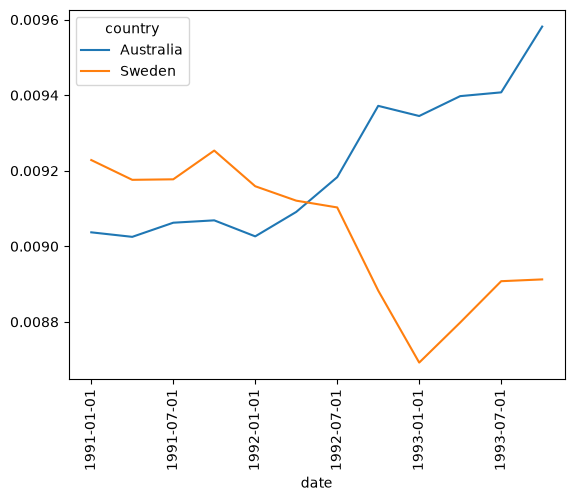

In [21]:
# Merge gdp and pop on date and country with fill
gdp_pop = pd.merge_ordered(gdp, pop, on=['country','date'], fill_method='ffill')

# Add a column named gdp_per_capita to gdp_pop that divides the gdp by pop
gdp_pop['gdp_per_capita'] = gdp_pop['gdp'] / gdp_pop['pop']

# Pivot data so gdp_per_capita, where index is date and columns is country
gdp_pivot = gdp_pop.pivot_table('gdp_per_capita', 'date', 'country')

# Select dates equal to or greater than 1991-01-01
recent_gdp_pop = gdp_pivot.query('date >= "1991-01-01"')

# Plot recent_gdp_pop
recent_gdp_pop.plot(rot=90)
plt.show()